In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime 
import os

In [4]:
file_path = "../data/Pharma_data_analysis.xlsx"
df = pd.read_excel(file_path)
print(f"Dataset shape: {df.shape}")

Dataset shape: (254082, 18)


In [5]:
print(f"Columns: {df.columns.tolist()}")
df.head()

Columns: ['Distributor', 'Customer Name', 'City', 'Country', 'Latitude', 'Longitude', 'Channel', 'Sub-channel', 'Product Name', 'Product Class', 'Quantity', 'Price', 'Sales', 'Month', 'Year', 'Name of Sales Rep', 'Manager', 'Sales Team']


,Distributor,Customer Name,City,Country,Latitude,Longitude,Channel,Sub-channel,Product Name,Product Class,Quantity,Price,Sales,Month,Year,Name of Sales Rep,Manager,Sales Team
0,Gottlieb-Cruickshank,"Zieme, Doyle and Kunze",Lublin,Poland,51.2333,22.5667,Hospital,Private,Topipizole,Mood Stabilizers,4.0,368,1472.0,January,2018,Mary Gerrard,Britanny Bold,Delta
1,Gottlieb-Cruickshank,Feest PLC,Åšwiecie,Poland,53.4167,18.4333,Pharmacy,Retail,Choriotrisin,Antibiotics,7.0,591,4137.0,January,2018,Jessica Smith,Britanny Bold,Delta
2,Gottlieb-Cruickshank,Medhurst-Beer Pharmaceutical Limited,Rybnik,Poland,50.0833,18.5000,Pharmacy,Institution,Acantaine,Antibiotics,30.0,66,1980.0,January,2018,Steve Pepple,Tracy Banks,Bravo
3,Gottlieb-Cruickshank,Barton Ltd Pharma Plc,CzeladÅº,Poland,50.3333,19.0833,Hospital,Private,Lioletine Refliruvax,Analgesics,6.0,435,2610.0,January,2018,Mary Gerrard,Britanny Bold,Delta
4,Gottlieb-Cruickshank,Keeling LLC Pharmacy,Olsztyn,Poland,53.7800,20.4942,Pharmacy,Retail,Oxymotroban Fexoformin,Analgesics,20.0,458,9160.0,January,2018,Anne Wu,Britanny Bold,Delta


In [ ]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
print(f"✅ Date column created: {df['Date'].min()} to {df['Date'].max()}")

✅ Date column created: 2017-01-01 00:00:00 to 2020-12-01 00:00:00


In [7]:
today = df['Date'].max()
print(f"📅 Today (reference date): {today}")

rfm = df.groupby('Customer Name').agg({
    'Date': lambda x: (today - x.max()).days,  # Recency
    'Customer Name': 'count',                   # Frequency
    'Sales': 'sum'                              # Monetary
}).rename(columns={
    'Date': 'Recency',
    'Customer Name': 'Frequency',
    'Sales': 'Monetary'
})

print(f"✅ RFM table created: {rfm.shape}")
rfm.head()

📅 Today (reference date): 2020-12-01 00:00:00
✅ RFM table created: (751, 3)


,Recency,Frequency,Monetary
Customer Name,,,
Abernathy Group,0,353,24876667.0
Abernathy Group Pharmaceutical Limited,731,223,2079222.0
Abernathy Group Pharmacy,0,390,34635271.0
Abernathy and Sons,0,376,20722227.0
Abernathy and Sons Pharmaceutical Limited,0,391,18857078.0


In [14]:
# Create RFM scores (1 to 5) - FIXED VERSION

# R_Score: Recency the less the better
# we had alot of Recency=0, so we will use a custom function to assign scores
def r_score(x):
    if x <= 30:
        return 5
    elif x <= 90:
        return 4
    elif x <= 180:
        return 3
    elif x <= 365:
        return 2
    else:
        return 1

rfm['R_Score'] = rfm['Recency'].apply(r_score)

# F_Score: Frequency the more the better
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# M_Score: Monetary the more the better
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

print("✅ RFM scores created")
rfm.head()


✅ RFM scores created


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Score_Numeric,Segment
Customer Name,,,,,,,,,
Abernathy Group,0,353,24876667.0,5,2,5,525,12,At Risk
Abernathy Group Pharmaceutical Limited,731,223,2079222.0,1,2,1,121,4,New
Abernathy Group Pharmacy,0,390,34635271.0,5,4,5,545,14,Champions
Abernathy and Sons,0,376,20722227.0,5,3,4,534,12,Loyal
Abernathy and Sons Pharmaceutical Limited,0,391,18857078.0,5,4,4,544,13,Champions


In [15]:
# Create overall RFM score
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score_Numeric'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

print("✅ Combined RFM score created")


✅ Combined RFM score created


In [16]:
# Segment customers based on RFM scores
def rfm_segment(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal'
    elif row['R_Score'] >= 2 and row['F_Score'] >= 2 and row['M_Score'] >= 2:
        return 'At Risk'
    elif row['R_Score'] == 1 and row['F_Score'] == 1 and row['M_Score'] == 1:
        return 'Lost'
    else:
        return 'New'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)
print("✅ Customer segments created")


✅ Customer segments created


In [17]:
# Segment distribution
print("\n📊 Customer segment distribution:")
print(rfm['Segment'].value_counts())
print("\n📊 Percentage:")
print(rfm['Segment'].value_counts(normalize=True) * 100)


📊 Customer segment distribution:
Segment
Loyal        192
Champions    185
At Risk      174
Lost         120
New           80
Name: count, dtype: int64

📊 Percentage:
Segment
Loyal        25.565912
Champions    24.633822
At Risk      23.169108
Lost         15.978695
New          10.652463
Name: proportion, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11296\1727194888.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, palette=colors)


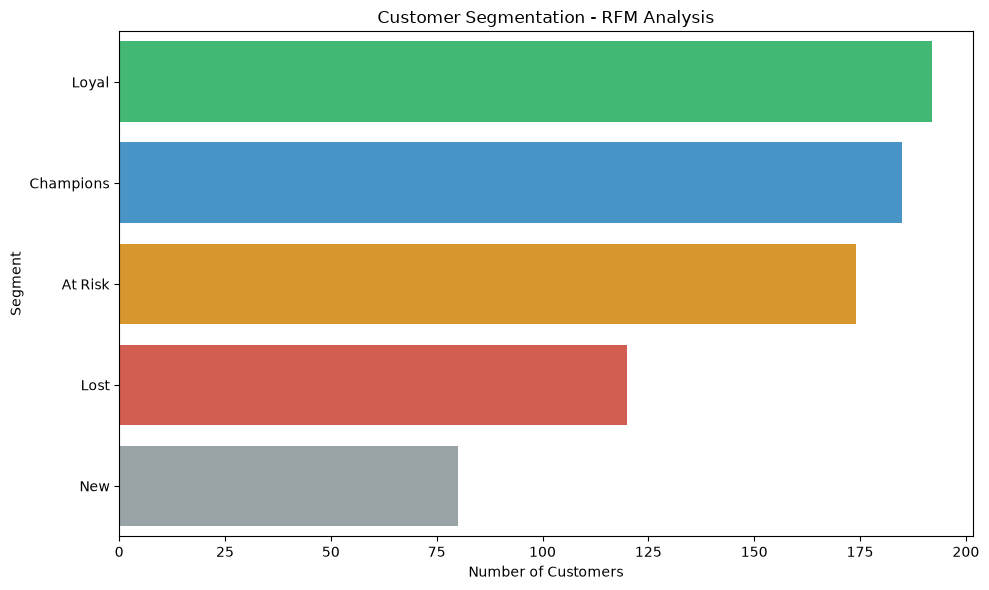

In [18]:
# Visualize segment distribution
plt.figure(figsize=(10,6))
segment_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette=colors)
plt.title('Customer Segmentation - RFM Analysis')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.savefig("../images/rfm_segments.png", dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# Save RFM results
rfm.to_csv("../data/rfm_results.csv")
print("✅ RFM results saved to ../data/rfm_results.csv")

✅ RFM results saved to ../data/rfm_results.csv


In [20]:
# Show top 10 Champions
print("\n🏆 Top 10 Champions (Best Customers):")
champions = rfm[rfm['Segment'] == 'Champions'].sort_values('Monetary', ascending=False).head(10)
print(champions[['Recency', 'Frequency', 'Monetary', 'RFM_Score']])


🏆 Top 10 Champions (Best Customers):
                                                    Recency  Frequency  \
Customer Name                                                            
Parker, Green and Emmerich Pharma Plc                     0        398   
Zemlak-Witting                                            0        386   
Moen, Murazik and Smith Pharm                             0        395   
Gleichner, Bahringer and Morar Pharmaceutical L...        0        388   
Romaguera, Moen and Hagenes Pharmacy                      0        420   
Torphy, Pfeffer and Jakubowski Pharm                      0        385   
Kuphal, Herzog and Purdy                                  0        421   
Raynor-Graham                                             0        392   
Goldner-Tillman Pharm                                     0        396   
Prohaska, Bogisich and Gutkowski Pharmaceutical...        0        387   

                                                        Monetary RFM_Scor